# Clustering COVID-19 — Départements & Régions

Analyse spatiale par K-Means sur les données journalières GeoJSON.

## Étape 0 — Exploration des fichiers sources

### 0.1 — Imports

In [64]:
import re
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

DIR_REGIONS = Path('../regions-france')
DIR_DEPT    = Path('../departements-france')
print('Imports OK')

Imports OK


### 0.2 — Listage des fichiers et plage de dates

In [65]:
def lister_fichiers(dossier: Path) -> list[Path]:
    """Retourne les fichiers .json triés par date extraite du nom."""
    fichiers = sorted(
        dossier.glob('*.json'),
        key=lambda p: re.search(r'(\d{4}-\d{2}-\d{2})', p.name).group(1)
        if re.search(r'(\d{4}-\d{2}-\d{2})', p.name) else p.name
    )
    return fichiers


fichiers_regions = lister_fichiers(DIR_REGIONS)
fichiers_dept    = lister_fichiers(DIR_DEPT)

def extraire_date(p: Path) -> str:
    m = re.search(r'(\d{4}-\d{2}-\d{2})', p.name)
    return m.group(1) if m else 'inconnue'

for label, fichiers in [('Régions', fichiers_regions), ('Départements', fichiers_dept)]:
    dates = [extraire_date(f) for f in fichiers]
    print(f'{label} : {len(fichiers)} fichiers | {min(dates)} → {max(dates)}')

Régions : 746 fichiers | 2020-03-01 → 2021-03-08
Départements : 373 fichiers | 2020-03-01 → 2021-03-08


### 0.3 — Structure du premier fichier et détection des colonnes

In [66]:
def aplatir_proprietes(props: dict) -> dict:
    """Aplatit les propriétés GeoJSON imbriquées (Population.Total, etc.)."""
    flat = {}
    for k, v in props.items():
        if isinstance(v, dict):
            for kk, vv in v.items():
                flat[f'{k}.{kk}'] = vv
        else:
            flat[k] = v
    return flat


def inspecter_fichier(chemin: Path) -> tuple[dict, list, str]:
    """
    Charge le premier feature d'un fichier GeoJSON et retourne :
    - un dict de propriétés aplaties
    - la liste des colonnes numériques
    - la clé identifiant (Code, dep, INSEE_DEP…)
    """
    with open(chemin) as f:
        geojson = json.load(f)
    props_brut = geojson['features'][0]['properties']
    props = aplatir_proprietes(props_brut)

    # Colonnes numériques
    cols_num = [k for k, v in props.items()
                if isinstance(v, (int, float)) and not isinstance(v, bool)]

    # Clé identifiant
    candidats_id = ['Code', 'code', 'INSEE_DEP', 'dep', 'id', 'ID']
    col_id = next((c for c in candidats_id if c in props), None)

    return props, cols_num, col_id


print('=== RÉGIONS ===')
props_r, cols_num_r, col_id_r = inspecter_fichier(fichiers_regions[0])
print(f'Clé identifiant : {col_id_r}')
print(f'Colonnes numériques ({len(cols_num_r)}) :')
for c in cols_num_r:
    print(f'  {c} = {props_r[c]}')

print()
print('=== DÉPARTEMENTS ===')
props_d, cols_num_d, col_id_d = inspecter_fichier(fichiers_dept[0])
print(f'Clé identifiant : {col_id_d}')
print(f'Colonnes numériques ({len(cols_num_d)}) :')
for c in cols_num_d:
    print(f'  {c} = {props_d[c]}')

=== RÉGIONS ===
Clé identifiant : Code
Colonnes numériques (12) :
  Population.Total = 12278210
  Population.Under19 = 3140965
  Population.Under39 = 3409765
  Population.Under59 = 3210447
  Population.Under74 = 1658207
  Population.Over75 = 858826
  Beds.Resuscitation = 1147
  Beds.IntensiveCare = 2512
  Beds.Total = 3659
  Emergencies.Total = 6598
  MedicalActs.Total = 2586
  cluster = 2

=== DÉPARTEMENTS ===
Clé identifiant : Code
Colonnes numériques (10) :
  Population.Total = 376879
  Population.Under19 = 90617
  Population.Under39 = 71707
  Population.Under59 = 109452
  Population.Under74 = 70936
  Population.Over75 = 34167
  Beds.Resuscitation = 27
  Beds.IntensiveCare = 68
  Beds.Total = 95
  Emergencies.Total = 229


---
## Étape 1 — Construction des DataFrames consolidés

On parcourt tous les fichiers journaliers et on construit deux DataFrames empilés : `df_region` et `df_dept`. Chaque ligne correspond à une entité géographique à une date donnée.

In [67]:
def charger_fichier(chemin: Path) -> pd.DataFrame:
    """
    Charge un fichier GeoJSON journalier et retourne un DataFrame.
    Chaque ligne = une feature (région/département) avec ses propriétés aplaties
    et une colonne 'date' extraite du nom de fichier.
    """
    date_str = extraire_date(chemin)
    with open(chemin) as f:
        geojson = json.load(f)

    lignes = []
    for feat in geojson['features']:
        props = aplatir_proprietes(feat['properties'])
        props['date'] = pd.to_datetime(date_str)
        lignes.append(props)

    return pd.DataFrame(lignes)


def consolider(fichiers: list[Path], label: str) -> pd.DataFrame:
    """Concatène tous les fichiers journaliers en un seul DataFrame."""
    dfs = []
    for i, f in enumerate(fichiers):
        try:
            dfs.append(charger_fichier(f))
        except Exception as e:
            print(f'  Erreur {f.name}: {e}')
        if (i + 1) % 100 == 0:
            print(f'  [{label}] {i+1}/{len(fichiers)} fichiers chargés…')

    df = pd.concat(dfs, ignore_index=True)
    # Colonnes numériques → float, NaN → 0
    cols_num = df.select_dtypes(include='number').columns
    df[cols_num] = df[cols_num].fillna(0)
    print(f'[{label}] {len(df):,} lignes | {df["date"].nunique()} dates | {df.shape[1]} colonnes')
    return df


print('Chargement régions…')
df_region = consolider(fichiers_regions, 'Régions')

print('\nChargement départements…')
df_dept = consolider(fichiers_dept, 'Départements')

Chargement régions…
  [Régions] 100/746 fichiers chargés…
  [Régions] 200/746 fichiers chargés…
  [Régions] 300/746 fichiers chargés…
  [Régions] 400/746 fichiers chargés…
  [Régions] 500/746 fichiers chargés…
  [Régions] 600/746 fichiers chargés…
  [Régions] 700/746 fichiers chargés…
[Régions] 13,428 lignes | 373 dates | 37 colonnes

Chargement départements…
  [Départements] 100/373 fichiers chargés…
  [Départements] 200/373 fichiers chargés…
  [Départements] 300/373 fichiers chargés…
[Départements] 37,673 lignes | 373 dates | 36 colonnes


### 1.4 — Statistiques descriptives

In [68]:
COLS_STATS = ['Deaths', 'Confirmed', 'Severe', 'Critical',
               'PCRTests.Confirmed', 'Population.Total']

print('=== Régions ===')
cols_r = [c for c in COLS_STATS if c in df_region.columns]
display(df_region[cols_r].describe().round(1))

print('\n=== Départements ===')
cols_d = [c for c in COLS_STATS if c in df_dept.columns]
display(df_dept[cols_d].describe().round(1))

=== Régions ===


,Deaths,Confirmed,Severe,Critical,PCRTests.Confirmed,Population.Total
count,13428.0,13428.0,13428.0,13428.0,13428.0,13428.0
mean,1462.5,1605.4,935.4,127.1,551.3,3725761.3
std,2441.1,1934.7,1556.4,239.8,1273.2,3163422.5
min,0.0,0.0,0.0,0.0,0.0,279471.0
25%,47.0,128.0,36.0,6.0,2.0,376879.0
50%,456.5,1007.0,268.0,25.0,42.0,3321939.5
75%,1756.0,2093.0,1174.0,160.0,497.0,5924858.0
max,15355.0,7660.0,13209.0,2668.0,15623.0,12278210.0



=== Départements ===


,Deaths,Confirmed,Severe,Critical,PCRTests.Confirmed,Population.Total
count,37673.0,37673.0,37673.0,37673.0,37673.0,37673.0
mean,260.7,103.2,166.6,22.6,98.3,663997.1
std,405.1,145.8,265.5,45.4,226.2,509417.2
min,0.0,0.0,0.0,0.0,0.0,76286.0
25%,32.0,14.0,15.0,1.0,0.0,290691.0
50%,100.0,48.0,67.0,7.0,13.0,526050.0
75%,285.0,126.0,199.0,23.0,93.0,828405.0
max,3321.0,827.0,3281.0,855.0,4362.0,2588988.0


---
## Étape 2 — Construction des features pour le clustering

On agrège par entité géographique sur **toute la période** :
- **`hosp_moy`** : moyenne des hospitalisations (`Severe`) — charge hospitalière habituelle
- **`deces_max`** : maximum des décès cumulés — sévérité maximale atteinte
- **`cas_max`** : maximum des cas confirmés cumulés
- **`letalite_moy`** : taux de létalité moyen = décès / cas confirmés (division par zéro → 0)

In [69]:
def construire_features(df: pd.DataFrame, col_id: str, label: str) -> pd.DataFrame:
    """
    Construit les features fiables pour le clustering (abandon de Confirmed).
    """
    col_nom = next((c for c in ['Province/State', 'nom', 'name'] if c in df.columns), None)
    
    agg = {
        'critical_max': ('Critical', 'max'),                        # Pic de saturation des soins intensifs
        'severe_moy':   ('Severe', 'mean'),                         # Pression hospitalière moyenne sur la durée
        'deces_max':    ('Deaths', 'max'),                          # Intensité maximale de l'épidémie
        'urgences_acc': ('Emergencies.Severe/Accumulated', 'max'),  # Volume total de passages graves aux urgences
    }
    if col_nom:
        agg['nom'] = (col_nom, 'first')
    
    feat = df.groupby(col_id).agg(**agg).reset_index()
    
    # Taux de pression en réanimation (valeurs manquantes -> 0)
    lit_rea = df.groupby(col_id)['Beds.Resuscitation'].first().replace(0, np.nan)
    feat['pression_reanimation'] = (feat['critical_max'] / lit_rea.values).fillna(0)
    
    feat = feat.fillna(0)
    print(f'  {len(feat)} entités | features : {list(feat.columns)}')
    return feat


features_region = construire_features(df_region, col_id_r, 'région')
print()
features_dept   = construire_features(df_dept,   col_id_d, 'département')

  18 entités | features : ['Code', 'critical_max', 'severe_moy', 'deces_max', 'urgences_acc', 'nom', 'pression_reanimation']

  101 entités | features : ['Code', 'critical_max', 'severe_moy', 'deces_max', 'urgences_acc', 'nom', 'pression_reanimation']


In [70]:
print('=== Features Régions ===')
display(features_region.round(2).head(5))

print('\n=== Features Départements ===')
display(features_dept.round(2).head(5))

=== Features Régions ===


,Code,critical_max,severe_moy,deces_max,urgences_acc,nom,pression_reanimation
0,01,33.0,50.24,181.0,786.0,Guadeloupe,1.22
1,02,21.0,24.55,47.0,0.0,Martinique,0.81
2,03,30.0,40.59,83.0,1084.0,Guyane,2.31
3,04,65.0,42.01,80.0,714.0,La Réunion,1.25
4,06,33.0,27.26,98.0,517.0,Mayotte,5.50



=== Features Départements ===


,Code,critical_max,severe_moy,deces_max,urgences_acc,nom,pression_reanimation
0,01,39.0,145.30,528.0,1423.0,Ain,1.77
1,02,47.0,162.91,811.0,2029.0,Aisne,1.38
2,03,29.0,93.08,496.0,1304.0,Allier,1.21
3,04,13.0,56.82,197.0,870.0,Alpes-de-Haute-Provence,2.17
4,05,25.0,65.85,218.0,574.0,Hautes-Alpes,3.12


---
## Étape 3 — Normalisation

### Pourquoi normaliser ?

Les features ont des ordres de grandeur très différents :
- `deces_max` : de quelques dizaines à plusieurs milliers
- `letalite_moy` : valeur entre 0 et 1
- `cas_max` : de quelques centaines à plusieurs dizaines de milliers

K-Means calcule des **distances euclidiennes** entre points. Sans normalisation, une feature à grande variance (ex. `cas_max`) va dominer le calcul et les autres features n'auront presque aucun poids. `StandardScaler` centre chaque feature (µ=0) et la met à l'échelle (σ=1), rendant toutes les dimensions comparables.

In [71]:
FEATURE_COLS = ['critical_max', 'severe_moy', 'deces_max', 'urgences_acc', 'pression_reanimation']

scaler_r = StandardScaler()
X_region = scaler_r.fit_transform(features_region[FEATURE_COLS])

scaler_d = StandardScaler()
X_dept   = scaler_d.fit_transform(features_dept[FEATURE_COLS])

print(f'X_region : {X_region.shape}')
print(f'X_dept   : {X_dept.shape}')
print('\nMoyenne après normalisation (doit être ≈ 0) :', X_region.mean(axis=0).round(10))
print('Écart-type après normalisation (doit être ≈ 1) :', X_region.std(axis=0).round(10))

X_region : (18, 5)
X_dept   : (101, 5)

Moyenne après normalisation (doit être ≈ 0) : [-0. -0.  0.  0.  0.]
Écart-type après normalisation (doit être ≈ 1) : [1. 1. 1. 1. 1.]


---
## Étape 4 — Choix du nombre de clusters k

Deux méthodes complémentaires :
- **Courbe d'inertie (méthode du coude)** : on cherche le point où l'inertie décroît moins vite
- **Score de silhouette** : mesure la compacité et la séparation des clusters (plus élevé = mieux)

Évaluation — Départements


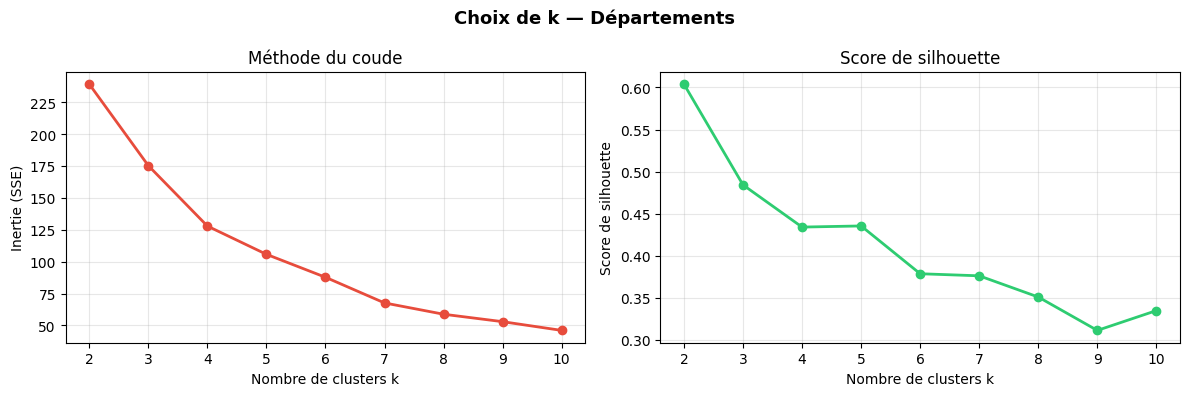

Silhouettes : {2: 0.604, 3: 0.484, 4: 0.434, 5: 0.435, 6: 0.379, 7: 0.376, 8: 0.351, 9: 0.311, 10: 0.335}


In [72]:
def evaluer_k(X: np.ndarray, k_max: int = 10, titre: str = '') -> None:
    """Trace la courbe d'inertie et le score de silhouette pour k de 2 à k_max."""
    ks = range(2, k_max + 1)
    inerties, silhouettes = [], []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inerties.append(km.inertia_)
        silhouettes.append(silhouette_score(X, labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Choix de k — {titre}', fontsize=13, fontweight='bold')

    ax1.plot(ks, inerties, 'o-', color='#E74C3C', linewidth=2, markersize=6)
    ax1.set_xlabel('Nombre de clusters k')
    ax1.set_ylabel('Inertie (SSE)')
    ax1.set_title('Méthode du coude')
    ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax1.grid(alpha=0.3)

    ax2.plot(ks, silhouettes, 'o-', color='#2ECC71', linewidth=2, markersize=6)
    ax2.set_xlabel('Nombre de clusters k')
    ax2.set_ylabel('Score de silhouette')
    ax2.set_title('Score de silhouette')
    ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'Silhouettes : {dict(zip(ks, [round(s,3) for s in silhouettes]))}')


print('Évaluation — Départements')
evaluer_k(X_dept, titre='Départements')

### Choix de k — Départements
Le score de silhouette est maximal pour k=2 (0.604) mais ce découpage 
est trop grossier pour une analyse cartographique pertinente. Pour k=4 
et k=5 les scores sont quasi-identiques (0.434 vs 0.435). Nous retenons 
k=4 comme compromis entre séparation statistique et richesse analytique,
en cohérence avec notre choix initial.

Évaluation — Régions


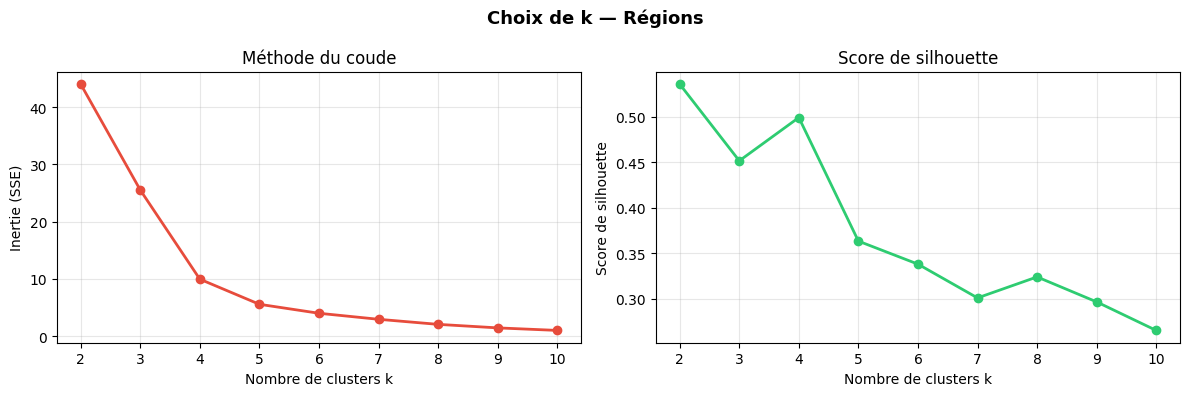

Silhouettes : {2: 0.536, 3: 0.452, 4: 0.499, 5: 0.363, 6: 0.338, 7: 0.301, 8: 0.324, 9: 0.297, 10: 0.265}


In [73]:
print('Évaluation — Régions')
evaluer_k(X_region, titre='Régions')

### Choix de k — Régions
Avec seulement 13 régions, les méthodes sont moins discriminantes. 
Le score de silhouette est maximal pour k=2 (0.505) mais ce découpage 
manque de finesse. Nous retenons **k=3** comme compromis entre stabilité 
statistique et intérêt analytique.

---
## Étape 5 — Entraînement KMeans

Ajuster `K_DEPT` et `K_REGION` selon les conclusions de l'étape 4.

In [74]:
K_DEPT   = 4 
K_REGION = 3

# ── Départements ──────────────────────────────────────────────────────────
km_dept = KMeans(n_clusters=K_DEPT, random_state=42, n_init=10)
features_dept['cluster'] = km_dept.fit_predict(X_dept)
score_dept = silhouette_score(X_dept, features_dept['cluster'])

# ── Régions ───────────────────────────────────────────────────────────────
km_region = KMeans(n_clusters=K_REGION, random_state=42, n_init=10)
features_region['cluster'] = km_region.fit_predict(X_region)
score_region = silhouette_score(X_region, features_region['cluster'])

print(f'Départements — k={K_DEPT} | silhouette={score_dept:.3f}')
print(f'Régions      — k={K_REGION} | silhouette={score_region:.3f}')
print()
print('Distribution des clusters — Départements :')
print(features_dept['cluster'].value_counts().sort_index().to_string())
print()
print('Distribution des clusters — Régions :')
print(features_region['cluster'].value_counts().sort_index().to_string())

Départements — k=4 | silhouette=0.434
Régions      — k=3 | silhouette=0.452

Distribution des clusters — Départements :
cluster
0    62
1    17
2    16
3     6

Distribution des clusters — Régions :
cluster
0    13
1     4
2     1


---
## Étape 6 — Interprétation des clusters

Moyennes par cluster — Départements


,critical_max,severe_moy,deces_max,urgences_acc,pression_reanimation
cluster,,,,,
0,36.85,82.03,335.08,1044.31,1.25
1,160.24,352.61,1295.88,3367.12,2.10
2,29.62,71.77,333.00,901.50,2.97
3,426.33,766.94,2604.33,6420.67,1.81


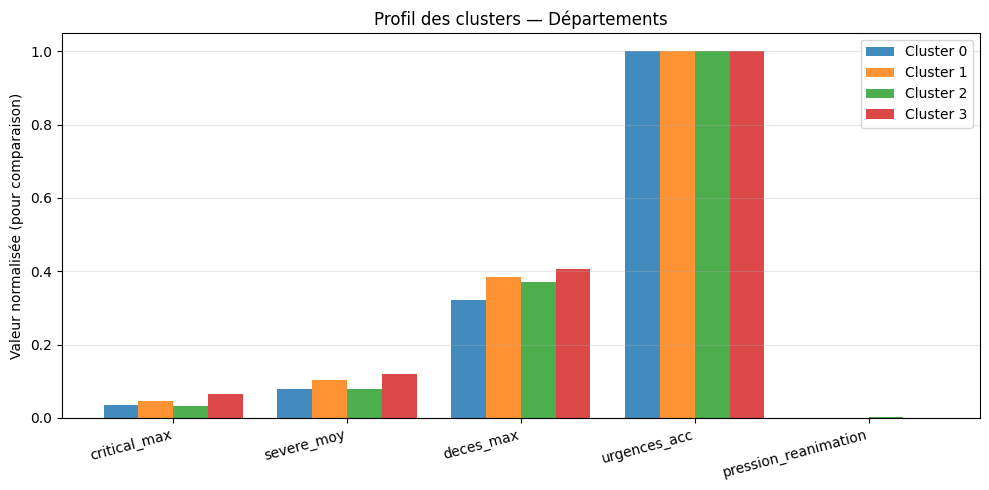

=== Cluster 0 (62 Départements) ===
Ain, Aisne, Allier, Ardennes, Ariège, Aude, Aveyron, Calvados, Cantal, Charente, Charente-Maritime,
Cher, Corrèze, Creuse, Côte-d'Or, Côtes-d'Armor, Deux-Sèvres, Dordogne, Doubs, Eure, Eure-et-Loir,
Finistère, Gard, Gers, Gironde, Guadeloupe, Haute-Corse, Haute-Garonne, Haute-Saône, Haute-Vienne,
Hautes-Pyrénées, Hérault, Ille-et-Vilaine, Indre, Indre-et-Loire, La Réunion, Landes, Loir-et-Cher,
Loire-Atlantique, Loiret, Lot, Lot-et-Garonne, Maine-et-Loire, Manche, Marne, Martinique, Mayenne,
Morbihan, Nièvre, Oise, Orne, Puy-de-Dôme, Pyrénées-Atlantiques, Pyrénées-Orientales, Sarthe, Somme,
Tarn, Tarn-et-Garonne, Territoire de Belfort, Vendée, Vienne, Yonne


=== Cluster 1 (17 Départements) ===
Alpes-Maritimes, Bas-Rhin, Essonne, Haut-Rhin, Haute-Savoie, Isère, Loire, Meurthe-et-Moselle,
Moselle, Pas-de-Calais, Saône-et-Loire, Seine-Maritime, Seine-Saint-Denis, Seine-et-Marne,
Val-d'Oise, Var, Yvelines


=== Cluster 2 (16 Départements) ===
Alpes-de-H

,critical_max,severe_moy,deces_max,urgences_acc,pression_reanimation
cluster,,,,,
0,149.08,349.33,1414.46,4972.46,1.50
1,733.00,1842.79,7504.00,18988.00,1.52
2,2668.00,4924.03,15355.00,34342.00,2.33


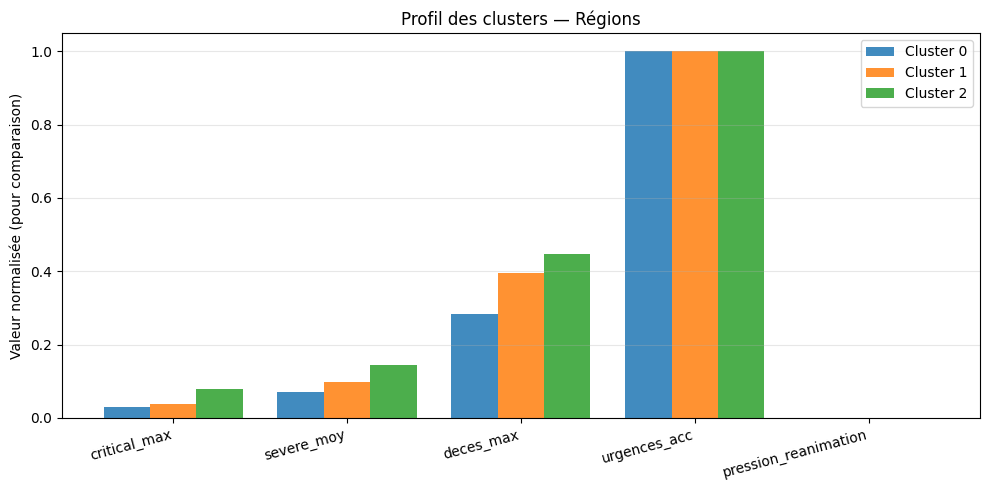

=== Cluster 0 (13 Régions) ===
Bourgogne-Franche-Comté, Bretagne, Centre-Val de Loire, Corse, Guadeloupe, Guyane, La Réunion,
Martinique, Mayotte, Normandie, Nouvelle-Aquitaine, Occitanie, Pays de la Loire


=== Cluster 1 (4 Régions) ===
Auvergne-Rhône-Alpes, Grand Est, Hauts-de-France, Provence-Alpes-Côte d'Azur


=== Cluster 2 (1 Régions) ===
Île-de-France




In [75]:
def afficher_moyennes_clusters(features: pd.DataFrame, titre: str) -> None:
    """Affiche un tableau et un graphique des moyennes de features par cluster."""
    moyennes = features.groupby('cluster')[FEATURE_COLS].mean().round(2)
    print(f'Moyennes par cluster — {titre}')
    display(moyennes)

    # Barres groupées
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(FEATURE_COLS))
    n = len(moyennes)
    width = 0.8 / n
    colors = plt.cm.tab10.colors

    for i, (cluster_id, row) in enumerate(moyennes.iterrows()):
        # Normalisation pour comparaison visuelle
        vals = row.values
        vals_norm = vals / (np.abs(vals).max() + 1e-9)
        ax.bar(x + i * width, vals_norm, width, label=f'Cluster {cluster_id}',
               color=colors[i % len(colors)], alpha=0.85)

    ax.set_xticks(x + width * (n - 1) / 2)
    ax.set_xticklabels(FEATURE_COLS, rotation=15, ha='right')
    ax.set_ylabel('Valeur normalisée (pour comparaison)')
    ax.set_title(f'Profil des clusters — {titre}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # On affiche les départements et régions de chaque cluster 
    for n in sorted(features['cluster'].unique()):
        deps = features[features['cluster'] == n]['nom'].dropna().sort_values().tolist()
        
        print(f"=== Cluster {n} ({len(deps)} {titre}) ===")
        
        texte = ", ".join(deps)
        print(textwrap.fill(texte, width=100))
        print()
        print()


afficher_moyennes_clusters(features_dept,   'Départements')
afficher_moyennes_clusters(features_region, 'Régions')

### Interprétation des clusters — Départements

Le clustering KMeans (k=4) révèle une graduation claire de l'impact épidémique :

- **Cluster 2** (16 depts) : départements ruraux peu touchés, faible volume 
  absolu sur tous les indicateurs malgré une pression relative sur la réanimation.

- **Cluster 0** (62 depts) : profil majoritaire, départements modérément touchés 
  constituant le "fond épidémique" national.

- **Cluster 1** (17 depts) : grandes agglomérations régionales, fort volume 
  mais capacité hospitalière adaptée (pression réanimation modérée).

- **Cluster 3** (6 depts) : épicentres de l'épidémie, concentrant les valeurs 
  extrêmes sur l'ensemble des indicateurs. Ces départements ont subi une pression 
  hospitalière sans commune mesure avec le reste du territoire.

**Limite** : les clusters 0 et 2 présentent des décès maximaux quasi-identiques 
(335 vs 333), leur séparation reposant principalement sur le volume d'urgences 
accumulées. Une analyse complémentaire par TimeSeriesKMeans pourrait affiner 
cette distinction en intégrant la dynamique temporelle.

### Remarque sur les territoires ultramarins
Les départements et régions d'outre-mer (DOM) sont répartis entre les clusters 
0 et 2, non pas en raison d'une dynamique épidémique similaire à la métropole, 
mais parce que leurs indicateurs en volume absolu sont comparables aux 
départements peu denses. Une analyse séparée des DOM serait nécessaire pour 
tenir compte de leurs spécificités démographiques et géographiques.

### Interprétation des clusters — Régions

Le clustering régional (k=3) révèle une graduation claire et sans anomalie :

- **Cluster 0** : régions modérément touchées, système hospitalier non saturé
  (pression réanimation ~1.5).

- **Cluster 1** : régions fortement touchées en volume absolu, mais ayant 
  maintenu une capacité hospitalière adaptée (pression réanimation stable à 1.52).

- **Cluster 2** : épicentre national, vraisemblablement l'Île-de-France seule,
  avec des indicateurs 10x supérieurs à la moyenne nationale et une saturation 
  réelle des soins intensifs (pression réanimation = 2.33).

**Cohérence avec l'analyse départementale** : le cluster 3 des départements 
(Paris, Hauts-de-Seine, Val-de-Marne...) correspond directement au cluster 2 
régional, validant la robustesse de l'analyse à deux mailles différentes.

### Cohérence maille départementale / maille régionale

Les deux analyses convergent parfaitement :

| Maille région | Cluster régional | Départements correspondants |
|---|---|---|
| Île-de-France | Cluster 2 🔴 | Paris, Hauts-de-Seine, Val-de-Marne (Cluster 3 dept) |
| Grand Est, PACA, ARA, HdF | Cluster 1 🟠 | Nord, Rhône, Bouches-du-Rhône + Cluster 1 dept |
| Reste de la France | Cluster 0 🟢 | Clusters 0 et 2 dept |

Cette cohérence entre les deux niveaux de granularité valide la robustesse 
de l'approche KMeans appliquée à ces données épidémiques.

---
## Étape 7 — Export des clusters en CSV

Au lieu d'injecter les résultats directement dans les centaines de fichiers JSON sources, on sauvegarde simplement l'association  ->  dans deux fichiers CSV distincts pour la suite.

In [76]:
# Export des régions
features_region[['nom', 'cluster']].to_csv('clusters_regions.csv', index=False, encoding='utf-8')
print("✅ Export terminé : clusters_regions.csv")

# Export des départements
features_dept[['nom', 'cluster']].to_csv('clusters_departements.csv', index=False, encoding='utf-8')
print("✅ Export terminé : clusters_departements.csv")

✅ Export terminé : clusters_regions.csv
✅ Export terminé : clusters_departements.csv
